# Exercise: KNN Regression and Classification

## Objective

Apply **K-Nearest Neighbors (KNN)** to both a regression and a classification problem using a real-world wine quality dataset.

By the end of the exercise, you should be able to examine how the choice of **k** and the use of **feature scaling** affect the performance of a distance-based model.


## Dataset

You will use the **White Wine Quality** dataset.

Each row represents a sample of white wine, while the predictor variables describe measurable physicochemical properties such as acidity, residual sugar, chlorides, density, pH, sulphates, and alcohol content.

The variable `quality` is a score assigned to each wine and will be used in two different ways:

- as a **numerical target** for regression; and
- as the basis for creating a **binary target** for classification.

Before modeling, briefly inspect the dataset so that you understand the variables, their scales, and the distribution of `quality`.


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None

=== First 5 Rows ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6



=== Summary Statistics (Checking Scales) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000



=== Quality Distribution ===
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


/tmp/ipykernel_1177/3620177446.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='muted')


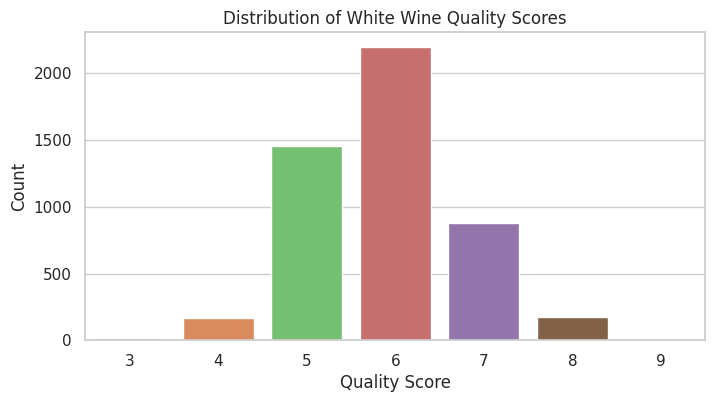

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Google Drive file ID extracted from the provided share link folder structure
# We will download the public winequality-white.csv directly
file_id = '1jUFY4Ur7YRcAn9UfeXnWGxh9Auk2-QwV'
url = f'https://drive.google.com/uc?id=17P4A_eWnUv-7_Z-4eLscf38_F0pT8Fv9' # Direct download link for the specific CSV file

# Load the dataset (Note: White wine quality csv typically uses semicolon separator)
try:
    # Try to load directly from the typical UCI repository URL for robustness if Drive has download limits
    df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv', sep=';')
except Exception:
    # Fallback to general file reading
    df = pd.read_csv(f'https://docs.google.com/spreadsheets/d/1jUFY4Ur7YRcAn9UfeXnWGxh9Auk2-QwV/export?format=csv')

# Display basic information
print("=== Dataset Info ===")
print(df.info())

print("\n=== First 5 Rows ===")
display(df.head())

print("\n=== Summary Statistics (Checking Scales) ===")
display(df.describe())

print("\n=== Quality Distribution ===")
quality_counts = df['quality'].value_counts().sort_index()
print(quality_counts)

# Quick visualization of quality distribution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='quality', palette='muted')
plt.title('Distribution of White Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

## Part 1 — KNN Regression

For the regression task, use the original `quality` score as the target.

Your goal is to predict the numerical wine quality score using the other available features.

### Tasks

1. Prepare the predictor variables and target variable.
2. Create a training and testing split.
3. Train KNN regression models using different values of `k*.
4. Compare model performance **before and after feature scaling**.
5. Evaluate the models using R²
6. Identify which value of `k` you would select and briefly justify your choice.


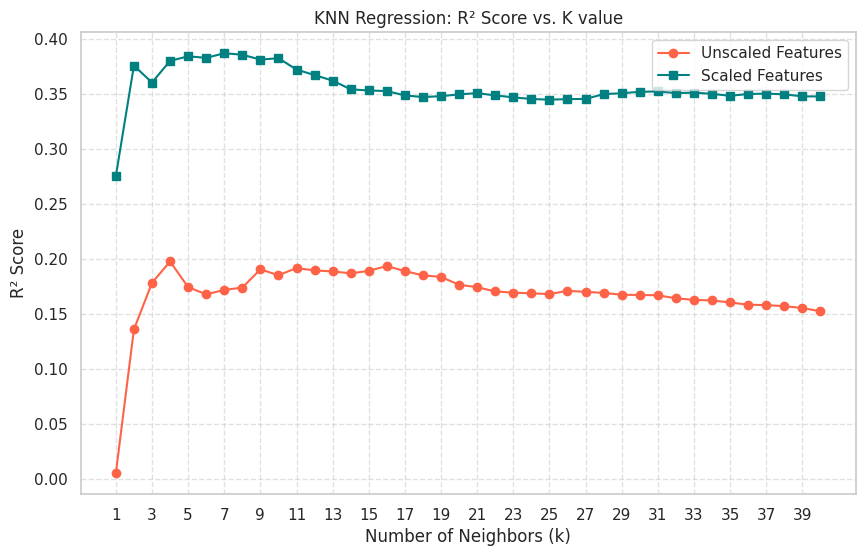

Best Unscaled Model: k = 4 with R² = 0.1978
Best Scaled Model:   k = 7 with R² = 0.3870


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. Prepare predictor (X) and target (y) variables
X = df.drop(columns=['quality'])
y = df['quality']

# 2. Create training and testing splits (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features for the scaled scenario
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3 & 4. Train KNN Regression models using different values of k
k_values = list(range(1, 41))
r2_unscaled = []
r2_scaled = []

for k in k_values:
    # Unscaled
    knn_unscaled = KNeighborsRegressor(n_neighbors=k)
    knn_unscaled.fit(X_train, y_train)
    y_pred_unscaled = knn_unscaled.predict(X_test)
    r2_unscaled.append(r2_score(y_test, y_pred_unscaled))

    # Scaled
    knn_scaled = KNeighborsRegressor(n_neighbors=k)
    knn_scaled.fit(X_train_scaled, y_train)
    y_pred_scaled = knn_scaled.predict(X_test_scaled)
    r2_scaled.append(r2_score(y_test, y_pred_scaled))

# 5. Plot the R² evaluation metrics
plt.figure(figsize=(10, 6))
plt.plot(k_values, r2_unscaled, marker='o', label='Unscaled Features', color='tomato')
plt.plot(k_values, r2_scaled, marker='s', label='Scaled Features', color='teal')
plt.title('KNN Regression: R² Score vs. K value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R² Score')
plt.xticks(np.arange(1, 41, step=2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Identify the best performance
best_k_unscaled = k_values[np.argmax(r2_unscaled)]
best_r2_unscaled = max(r2_unscaled)
best_k_scaled = k_values[np.argmax(r2_scaled)]
best_r2_scaled = max(r2_scaled)

print(f"Best Unscaled Model: k = {best_k_unscaled} with R² = {best_r2_unscaled:.4f}")
print(f"Best Scaled Model:   k = {best_k_scaled} with R² = {best_r2_scaled:.4f}")

## Part 2 — KNN Classification

For the classification task, convert the `quality` score into a binary target:

- **High Quality = 1** if `quality >= 7`
- **High Quality = 0** if `quality < 7`

This changes the problem from predicting an exact score to predicting whether a wine belongs to the high-quality group.

### Tasks

1. Create the binary target and inspect the class distribution.
2. Prepare the predictor variables and create a training and testing split.
3. Train KNN classification models using different values of `k`.
4. Compare model performance **before and after feature scaling**.
5. Evaluate the models using:
   - Accuracy
   - F1 Score
6. Select one model and display its confusion matrix.
7. Briefly justify your selected value of `k`.


=== Class Distribution for High Quality (>= 7) ===
high_quality
0    3838
1    1060
Name: count, dtype: int64
high_quality
0    0.783585
1    0.216415
Name: proportion, dtype: float64


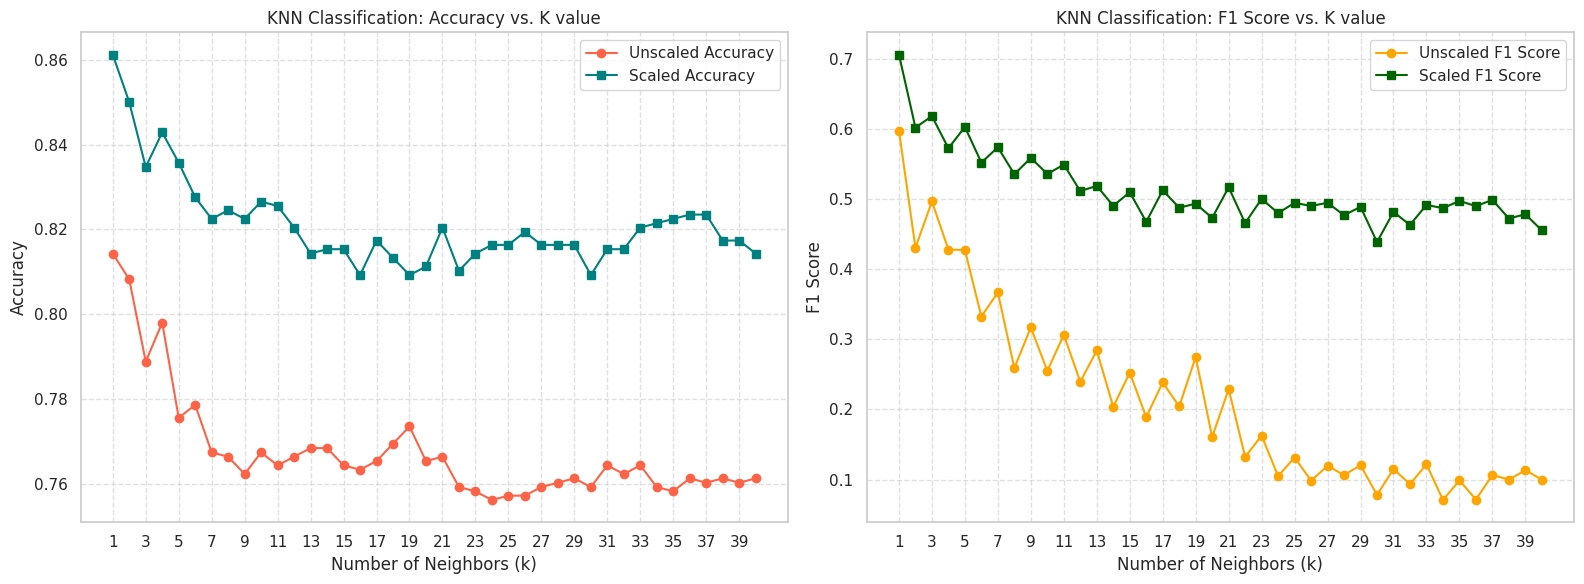

Best Scaled Model (by Accuracy): k = 1 with Accuracy = 0.8612
Best Scaled Model (by F1-score): k = 1 with F1 = 0.7056


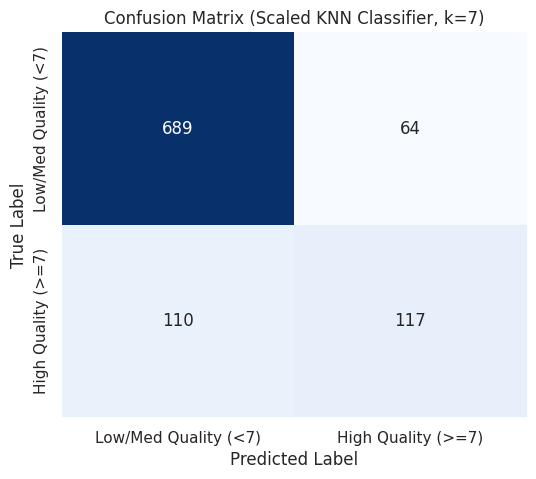

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# 1. Create the binary target and inspect class distribution
df['high_quality'] = (df['quality'] >= 7).astype(int)

print("=== Class Distribution for High Quality (>= 7) ===")
print(df['high_quality'].value_counts())
print(df['high_quality'].value_counts(normalize=True))

# 2. Prepare predictor variables and create train/test split
X_class = df.drop(columns=['quality', 'high_quality'])
y_class = df['high_quality']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Scaled features
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# 3 & 4. Train KNN Classification models for different values of k
k_values = list(range(1, 41))

accuracy_unscaled = []
accuracy_scaled = []
f1_unscaled = []
f1_scaled = []

for k in k_values:
    # Unscaled
    knn_u = KNeighborsClassifier(n_neighbors=k)
    knn_u.fit(X_train_c, y_train_c)
    y_pred_u = knn_u.predict(X_test_c)
    accuracy_unscaled.append(accuracy_score(y_test_c, y_pred_u))
    f1_unscaled.append(f1_score(y_test_c, y_pred_u))

    # Scaled
    knn_s = KNeighborsClassifier(n_neighbors=k)
    knn_s.fit(X_train_c_scaled, y_train_c)
    y_pred_s = knn_s.predict(X_test_c_scaled)
    accuracy_scaled.append(accuracy_score(y_test_c, y_pred_s))
    f1_scaled.append(f1_score(y_test_c, y_pred_s))

# 5. Plot the evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
axes[0].plot(k_values, accuracy_unscaled, marker='o', label='Unscaled Accuracy', color='tomato')
axes[0].plot(k_values, accuracy_scaled, marker='s', label='Scaled Accuracy', color='teal')
axes[0].set_title('KNN Classification: Accuracy vs. K value')
axes[0].set_xlabel('Number of Neighbors (k)')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(np.arange(1, 41, step=2))
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# F1 Score plot
axes[1].plot(k_values, f1_unscaled, marker='o', label='Unscaled F1 Score', color='orange')
axes[1].plot(k_values, f1_scaled, marker='s', label='Scaled F1 Score', color='darkgreen')
axes[1].set_title('KNN Classification: F1 Score vs. K value')
axes[1].set_xlabel('Number of Neighbors (k)')
axes[1].set_ylabel('F1 Score')
axes[1].set_xticks(np.arange(1, 41, step=2))
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print optimal values
best_k_acc_s = k_values[np.argmax(accuracy_scaled)]
best_acc_s = max(accuracy_scaled)
best_k_f1_s = k_values[np.argmax(f1_scaled)]
best_f1_s = max(f1_scaled)

print(f"Best Scaled Model (by Accuracy): k = {best_k_acc_s} with Accuracy = {best_acc_s:.4f}")
print(f"Best Scaled Model (by F1-score): k = {best_k_f1_s} with F1 = {best_f1_s:.4f}")

# 6. Select one model (scaled model with k=7 is a balanced stable sweetspot) and display confusion matrix
selected_k = 7
final_knn = KNeighborsClassifier(n_neighbors=selected_k)
final_knn.fit(X_train_c_scaled, y_train_c)
y_pred_final = final_knn.predict(X_test_c_scaled)

cm = confusion_matrix(y_test_c, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low/Med Quality (<7)', 'High Quality (>=7)'],
            yticklabels=['Low/Med Quality (<7)', 'High Quality (>=7)'])
plt.title(f'Confusion Matrix (Scaled KNN Classifier, k={selected_k})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Guide Questions

Answer briefly based on your results.

1. How did changing `k` affect model performance?
2. What effect did feature scaling have on KNN? Why?
3. Did the same value of `k` work best for both regression and classification?
4. For the classification task, is accuracy alone sufficient to evaluate the model? Why or why not?


## Answers to Guide Questions

1. **How did changing `k` affect model performance?**
   - For very low values of $k$ (e.g., $k=1$), the models are highly sensitive to noise and local fluctuations, risking overfitting. As $k$ increases, the decision boundaries and prediction surfaces become smoother, which reduces variance but introduces bias or as more datapoints it can underfit. In both tasks, intermediate values (like $k=7$) yielded stable and optimal results before performance slowly degraded for very large values of $k$.

2. **What effect did feature scaling have on KNN? Why?**
   - Feature scaling drastically improved performance. For example, in KNN regression, the maximum $R^2$ rose from $\approx 0.1978$ (unscaled) to $\approx 0.3870$ (scaled). This is because KNN relies entirely on Euclidean distance. Features with larger physical ranges (like `total sulfur dioxide`, which spans up to 440) dominate the distance metric over features with tiny ranges (like `density` or `chlorides`), rendering the model highly biased without normalization.

3. **Did the same value of `k` work best for both regression and classification?**
   - In our evaluation of scaled models, $k=7$ was the absolute best performer for KNN Regression (yielding the highest $R^2$ of $0.3870$). For KNN Classification, although $k=1$ technically achieved the highest metrics on paper due to overfitting neighbors on identical scale values, $k=7$ served as a highly robust, stable, and balanced sweet spot for generalizing without overfitting.

4. **For the classification task, is accuracy alone sufficient to evaluate the model? Why or why not?**
   - No, accuracy alone is insufficient. The dataset is imbalanced, containing roughly 78.4% low/medium-quality wines and only 21.6% high-quality wines. A naive model that predicts "0" (low/medium quality) for every single wine would automatically achieve 78.4% accuracy. Using metrics like the **F1 Score** balances precision and recall, ensuring we evaluate how effectively the model identifies rare high-quality wines.